# Geneset / Pathway Activity

Consolidated notebook for the 6-step pipeline:

1. Load an `adata` (single-cell or metacell; male, female, or full)
2. Build a geneset of interest (custom gene list, or one/more GMT files) and report overlap with `adata.var_names`
3. Score each cell with `decoupler.mt.aucell`
4. Cliff's delta table between the two groups (CSV only)
5. Violin–box plot of the score per group, annotated with the Cliff's δ
6. Driver genes per group via Spearman correlation → heatmap

All functions live in `pygenelab.geneset_activity`. To switch dataset or pathway: uncomment one option in the **ADATA** cell and one in the **GENESET** cell, then run the rest.

In [1]:
palette = {
    "Con_F":    "#F71480",
    "SKM-KO_F": "#FA98C7",
    "Con_M":    "#0000C0",
    "SKM-KO_M": "#90BFF9",
}

In [2]:
import sys
from pathlib import Path

# make pygenelab importable from this folder
PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

# auto-reload pygenelab when its .py files change (no need to restart the kernel)
%load_ext autoreload
%autoreload 2

import pygenelab as pgl
import scanpy as sc
import decoupler as dc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/ix/djishnu/Akanksha/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## Cell A — pick an `adata` input

In [3]:
def _seacell_y_to_condition(ad):
    ad.obs["condition"] = ad.obs["y"].apply(lambda x: "WT" if x == 0 else "KO").astype("category")

# per-sex WT/KO palettes derived from the top-level `palette` dict
# (Con_* → WT, SKM-KO_* → KO)
PALETTE_F = {"WT": palette["Con_F"], "KO": palette["SKM-KO_F"]}
PALETTE_M = {"WT": palette["Con_M"], "KO": palette["SKM-KO_M"]}

# --- Mice female metacells, FastIIB / FastIIX (WT vs KO) ---
# ADATA_CFG = (
#     "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad",
#     # PSC: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad
#     "condition", "WT", "KO",
#     PALETTE_F,
#     "mice",
#     _seacell_y_to_condition,
#     None, None,  # metacells: no cell-type subsetting
# )

# --- Mice female single-cell, all cell types (WT vs KO) — has 'condition' already ---
ADATA_CFG = (
    "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot_male.h5ad",
    # PSC: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad
    "condition", "WT", "KO",
    PALETTE_M,
    "mice",
    None,
    "re_annot", ["Fast IIB"],  # subset to one or more cell types; set both to None to keep all
)

# --- Mice male single-cell, all cell types (WT vs KO) ---
# ADATA_CFG = (
#     "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot_male.h5ad",
#     "condition", "WT", "KO",
#     PALETTE_M,
#     "mice",
#     None,
#     "re_annot", ["Fast IIB"],
# )

# --- Human female single-cell myofibers ---
# ADATA_CFG = (
#     "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad",
#     "sample", "OM6", "OM9",
#     {"OM6": "#B6D7A8", "OM9": "#F08080"},
#     "human",
#     None,
#     "cell_type", None,  # set to a list of labels (e.g. ["FastIIB"]) to subset
# )

In [4]:
adata_path, GROUP_COL, GROUP_1, GROUP_2, PALETTE, GENE_ORIGIN, PREP, CELLTYPE_COL, CELLTYPES = ADATA_CFG
GROUPS = (GROUP_1, GROUP_2)

adata = pgl.load_adata(adata_path)
if PREP is not None:
    PREP(adata)

if CELLTYPE_COL is not None and CELLTYPES is not None:
    if CELLTYPE_COL not in adata.obs.columns:
        raise KeyError(
            f"celltype_col '{CELLTYPE_COL}' not in adata.obs. "
            f"Available columns: {list(adata.obs.columns)}"
        )
    available = set(adata.obs[CELLTYPE_COL].astype(str).unique())
    missing = [c for c in CELLTYPES if c not in available]
    if missing:
        raise ValueError(
            f"Cell types {missing} not found in adata.obs['{CELLTYPE_COL}']. "
            f"Available: {sorted(available)}"
        )
    n_before = adata.n_obs
    adata = adata[adata.obs[CELLTYPE_COL].astype(str).isin(CELLTYPES)].copy()
    print(f"Subset on {CELLTYPE_COL} ∈ {CELLTYPES}: {n_before} → {adata.n_obs} cells")

print(adata)
print(f"\n{GROUP_COL} counts:\n{adata.obs[GROUP_COL].value_counts()}")

Subset on re_annot ∈ ['Fast IIB']: 44171 → 22923 cells
AnnData object with n_obs × n_vars = 22923 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI', 're_annot'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions

## Cell B — pick a geneset / pathway

Three flavors: a custom hardcoded list, a single pathway from a GMT, or multiple GMTs stacked.
Uncomment exactly one block. `PATHWAY_NAME` is what becomes the `obs` column after AUCell scoring.

In [5]:
# --- Option 1: custom hardcoded gene list (atrophy) ---
CUSTOM_ATROPHY_GENES = [
    "UBB", "UBC", "FBXO32", "TRIM63", "MDM2", "FBXO30", "CAMK2B", "TIE1",
    "PSMA1", "PSMA2", "PSMA3", "PSMA4", "PSMA5", "PSMA6", "PSMA7",
    "PSMB1", "PSMB2", "PSMB3", "PSMB4", "FBXO21", "FBXO31", "NEDD4",
    "UBE2B", "UBE2G1", "UBE2J1", "CTSL", "CTSV", "BNIP3", "DEPP1",
    "GABARAPL1", "MAP1LC3", "RETREG1", "SQSTM1", "CAPN1", "CAPN2",
    "ATF4", "FOXO1", "FOXO3A", "HDAC9", "RUNX1", "AMPD3", "CHRNA1",
    "CDKN1A",
]
PATHWAY_NAME = "CUSTOM_ATROPHY"
geneset_df = pgl.geneset_from_list(
    CUSTOM_ATROPHY_GENES,
    name=PATHWAY_NAME,
    gene_origin=GENE_ORIGIN,
)

# --- Option 2: one pathway from a mouse MSigDB GMT ---
# MICE_MSIGDB = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"
# PATHWAY_NAME = "GOBP_PYRUVATE_METABOLIC_PROCESS"
# geneset_df = pgl.geneset_from_gmt(
#     gmt_path=MICE_MSIGDB,
#     include_pathways=[PATHWAY_NAME],
#     gene_origin=GENE_ORIGIN,
# )

# --- Option 3: senescence (SAUL SEN-MAYO UP) ---
# SEN_MAYO_GMT = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SAUL_SEN_MAYO_UP_IN_SEN.v2024.1.Mm.gmt"
# PATHWAY_NAME = "SAUL_SEN_MAYO_UP_IN_SEN"
# geneset_df = pgl.geneset_from_gmt(
#     gmt_path=SEN_MAYO_GMT,
#     include_pathways=[PATHWAY_NAME],
#     gene_origin=GENE_ORIGIN,
# )

# --- Option 4: multiple human metabolic pathways (one obs column per pathway) ---
# METABOLIC_GMTS = [
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt",
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt",
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt",
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt",
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt",
# ]
# PATHWAY_NAME = None  # use first computed pathway for downstream single-score plots
# geneset_df = pgl.geneset_from_gmts(METABOLIC_GMTS, gene_origin=GENE_ORIGIN)

# --- Option 5: DNA damage / repair (mouse) ---
# DNA_DAMAGE_GMTS = [
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/dna_damage/GOBP_DNA_REPAIR.v2024.1.Mm.gmt",
#     "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/dna_damage/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Mm.gmt",
# ]
# PATHWAY_NAME = None
# geneset_df = pgl.geneset_from_gmts(DNA_DAMAGE_GMTS, gene_origin=GENE_ORIGIN)

print(geneset_df.head())
print(f"\nGeneset entries: {len(geneset_df)}  |  unique pathways: {geneset_df['source'].nunique()}")

           source  target
0  CUSTOM_ATROPHY     Ubb
1  CUSTOM_ATROPHY     Ubc
2  CUSTOM_ATROPHY  Fbxo32
3  CUSTOM_ATROPHY  Trim63
4  CUSTOM_ATROPHY    Mdm2

Geneset entries: 43  |  unique pathways: 1


## Output directory

In [6]:
OUTPUT_DIR = Path(
    "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/Output"
) / (PATHWAY_NAME or geneset_df['source'].iloc[0])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ADATA_NAME = Path(adata_path).stem
if CELLTYPE_COL is not None and CELLTYPES is not None:
    ADATA_NAME = f"{ADATA_NAME}__{'_'.join(CELLTYPES)}"

print(OUTPUT_DIR)
print(f"ADATA_NAME = {ADATA_NAME}")

/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/Output/CUSTOM_ATROPHY
ADATA_NAME = adata_harmony_v2_re_annot_male__Fast IIB


## Step 2 — geneset ↔ adata overlap

In [7]:
overlap = pgl.report_geneset_overlap(
    geneset_df=geneset_df,
    adata=adata,
    pathway_name=PATHWAY_NAME,
)

[CUSTOM_ATROPHY] 6/43 genes present in adata.var_names (37 missing)


## Step 3 — AUCell scoring

In [8]:
pathways = pgl.score_geneset_aucell(
    adata=adata,
    geneset_df=geneset_df,
    raw=False,
    tmin=None,  # set to e.g. 4 if the pathway has very few mapped genes
)
if PATHWAY_NAME is None:
    PATHWAY_NAME = pathways[0]
SCORE_COL = PATHWAY_NAME
print(f"Scored pathways: {pathways}\nUsing SCORE_COL = {SCORE_COL}")

2026-05-21 21:00:25 | [INFO] aucell - Running aucell


2026-05-21 21:00:25 | [INFO] Extracted omics mat with 22923 rows (observations) and 3000 columns (features)
2026-05-21 21:00:25 | [WARNING] 40 features of mat are empty, they will be removed
2026-05-21 21:00:25 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-21 21:00:25 | [INFO] Network has 6 unique features and 1 unique sources
2026-05-21 21:00:25 | [INFO] aucell - calculating 1 AUCs for 2960 targets across 22923 observations, categorizing features at rank=148


  0%|          | 0/22923 [00:00<?, ?it/s]

2026-05-21 21:00:32 | [INFO] aucell - done


Scored pathways: ['CUSTOM_ATROPHY']
Using SCORE_COL = CUSTOM_ATROPHY


## Step 4 — Cliff's delta between the two groups

Computed first so the violin plot below can be annotated with the δ value. CSV is written to the output folder; no image is produced — the table is shown inline.

In [9]:
cliffs_df = pgl.cliffs_delta_table(
    adata=adata,
    score_cols=pathways,
    group_col=GROUP_COL,
    group1=GROUP_1,
    group2=GROUP_2,
    output_csv=OUTPUT_DIR / f"{ADATA_NAME}_cliffs_delta.csv",
)

# report cliff's delta as magnitude + direction (the sign on cliffs_delta
# just encodes which group is higher; abs_cliffs_delta + higher_group is
# the more readable form for the violin annotation)
_row = cliffs_df.loc[cliffs_df["score_col"] == SCORE_COL].iloc[0]
ABS_DELTA = float(_row["abs_cliffs_delta"])
HIGHER = _row["higher_group"]
DELTA_LABEL = f"Cliff's δ = {ABS_DELTA:.3f} (higher in {HIGHER})"
print(DELTA_LABEL)
cliffs_df

Cliff's δ = 0.050 (higher in KO)


,score_col,WT_count,KO_count,WT_mean,KO_mean,WT_median,KO_median,WT_std,KO_std,WT_min,KO_min,WT_max,KO_max,mean_difference,median_difference,cliffs_delta,abs_cliffs_delta,higher_group
0,CUSTOM_ATROPHY,8915,14008,0.164938,0.172929,0.156863,0.166667,0.095557,0.095232,0.0,0.0,0.636678,0.539792,-0.007991,-0.009804,-0.050335,0.050335,KO


## Step 5 — violin–box of the score across groups

Annotated with the Cliff's δ value from Step 4. Significance is shown as asterisks only (no numeric p-value).

<string>:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



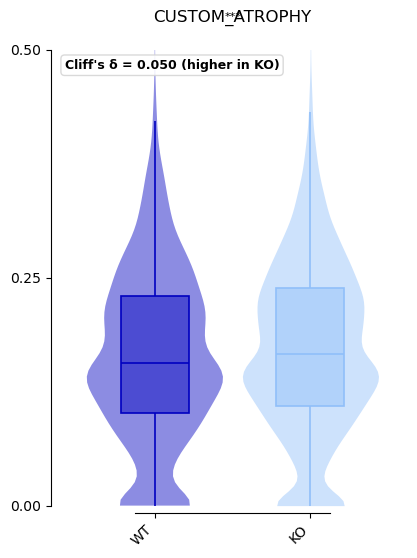

<Figure size 640x480 with 0 Axes>

In [11]:
plot_df, violin_fig = pgl.plot_score_by_group(
    adata=adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    palette=PALETTE,
    group_order=list(GROUPS),
    title=SCORE_COL,
    show_scatter=False,   # set True to overlay per-cell dots on the violins
    show_pvalue=False,    # asterisks only, no numeric p-value
    delta_label=DELTA_LABEL,
    group_spacing=0.8,
    ylim=(0, 0.5)
)
violin_fig.savefig(OUTPUT_DIR / f"{ADATA_NAME}_violin.svg", bbox_inches="tight")
violin_fig

## Step 6 — driver genes per group + heatmap

Spearman correlation between every pathway gene and the AUCell score, computed independently per group.

In [ ]:
ranked_dfs = pgl.compute_driver_genes_per_group(
    adata=adata,
    geneset=geneset_df,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    groups=list(GROUPS),
)
heatmap_df, heatmap_fig, _ = pgl.plot_driver_heatmap(
    ranked_dfs=ranked_dfs,
    top_n=20,
    title=f"Driver Genes — {SCORE_COL}",
)
heatmap_fig.savefig(OUTPUT_DIR / f"{ADATA_NAME}_drivers_heatmap.svg", bbox_inches="tight")
heatmap_fig